In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn

0 0.0012763862032443285
100 0.06981157511472702
200 0.122856505215168
300 0.12877896428108215
400 0.10062775760889053
500 0.11584074050188065
600 0.13670898973941803
700 0.09676548838615417
800 0.06064864993095398
900 0.058932796120643616


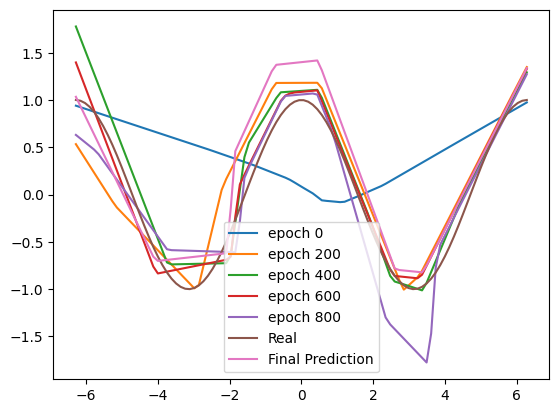

In [7]:
class CosModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(1, 16)
        self.layer2 = nn.Linear(16, 16)
        self.layer3 = nn.Linear(16, 1)
        self.criterion = nn.MSELoss()
        self.activation = nn.LeakyReLU()
        self.optimizer = torch.optim.Adam(self.parameters(), lr=0.01)
    def forward(self, x):
        x = self.layer1(x)
        x = self.activation(x)
        x = self.layer2(x)
        x = self.activation(x)
        x = self.layer3(x)
        return x
    def predict(self, X):
        self.eval()
        if type(X) == np.ndarray:
            X = torch.from_numpy(X).float()
        if len(X.shape) == 1:
            X = X.unsqueeze(1)
            with torch.no_grad():
                return self.forward(X)
        X = torch.from_numpy(X).float()
        with torch.no_grad():
            y = torch.zeros(X.shape[0], 1)
            for i, x in enumerate(X):
                y[i] = self.forward(x)
            return y
    def fit(self, X, Y, epochs:int=int(1e3), verbose:bool=False, plot:bool=False):
        self.train()
        X = torch.from_numpy(X).float()
        Y = torch.from_numpy(Y).float()
        for epoch in range(epochs):
            self.optimizer.zero_grad()
            loss = torch.zeros(1)
            for x, y in zip(X, Y):
                x = x.unsqueeze(-1)
                y = y.unsqueeze(-1)
                pred = self.forward(x)
                loss = self.criterion(pred, y)
                loss.backward()
                self.optimizer.step()
                self.optimizer.zero_grad()
            if epoch % 100 == 0 and verbose:
                print(epoch, loss.item())
            if epoch % 200 == 0 and plot:
                pred = self.predict(X)
                plt.plot(X, pred, label=f'epoch {epoch}')

X = np.linspace(-2*np.pi, 2*np.pi, 100)
Y = np.cos(X)
model = CosModel()
model.fit(X, Y, verbose=True, plot=True)
pred = model.predict(X)
plt.plot(X, Y, label='Real')
plt.plot(X, pred, label='Final Prediction')
plt.legend()
plt.show()